**Data Visualization**

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


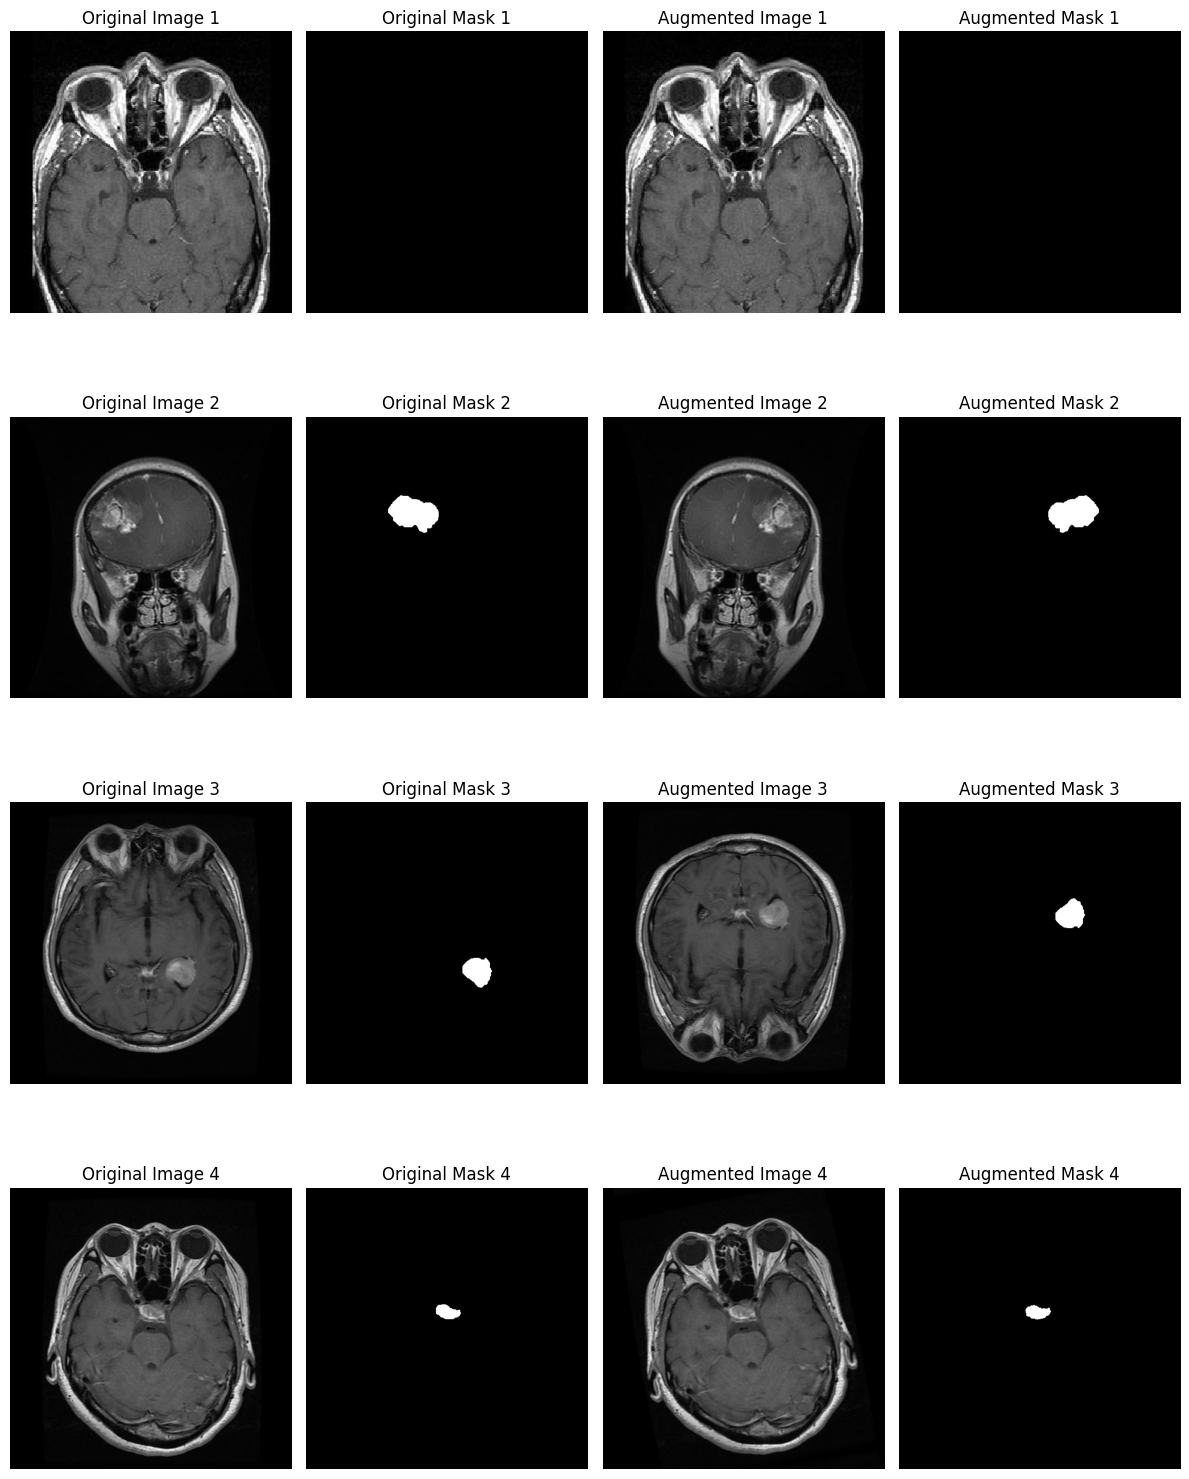

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2


def load_image_mask(image_path, mask_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return image, mask


def apply_augmentation(image, mask, transform):
    augmented = transform(image=image, mask=mask)
    return augmented['image'], augmented['mask']


base_path = "/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/"
image_paths = [
    (f"{base_path}image/0/Tr-noTr_0000.jpg", f"{base_path}mask/0/Tr-noTr_0000_m.jpg"),  # No Tumor
    (f"{base_path}image/1/Tr-glTr_0000.jpg", f"{base_path}mask/1/Tr-glTr_0000_m.jpg"),  # Glioma
    (f"{base_path}image/2/Tr-meTr_0001.jpg", f"{base_path}mask/2/Tr-meTr_0001_m.jpg"),  # Meningioma
    (f"{base_path}image/3/Tr-piTr_0000.jpg", f"{base_path}mask/3/Tr-piTr_0000_m.jpg")   # Pituitary
]


transformations = [
    A.NoOp(), 
    A.HorizontalFlip(p=1),  
    A.VerticalFlip(p=1),  
    A.Rotate(limit=45, p=1)  
]


fig, axs = plt.subplots(4, 4, figsize=(12, 16))

for i, (img_path, mask_path) in enumerate(image_paths):
    img, mask = load_image_mask(img_path, mask_path)
    aug_img, aug_mask = apply_augmentation(img, mask, transformations[i])

    axs[i, 0].imshow(img)
    axs[i, 0].set_title(f"Original Image {i+1}")
    axs[i, 0].axis("off")

    axs[i, 1].imshow(mask, cmap="gray")
    axs[i, 1].set_title(f"Original Mask {i+1}")
    axs[i, 1].axis("off")

    axs[i, 2].imshow(aug_img)
    axs[i, 2].set_title(f"Augmented Image {i+1}")
    axs[i, 2].axis("off")

    axs[i, 3].imshow(aug_mask, cmap="gray")
    axs[i, 3].set_title(f"Augmented Mask {i+1}")
    axs[i, 3].axis("off")

plt.tight_layout()
plt.show()


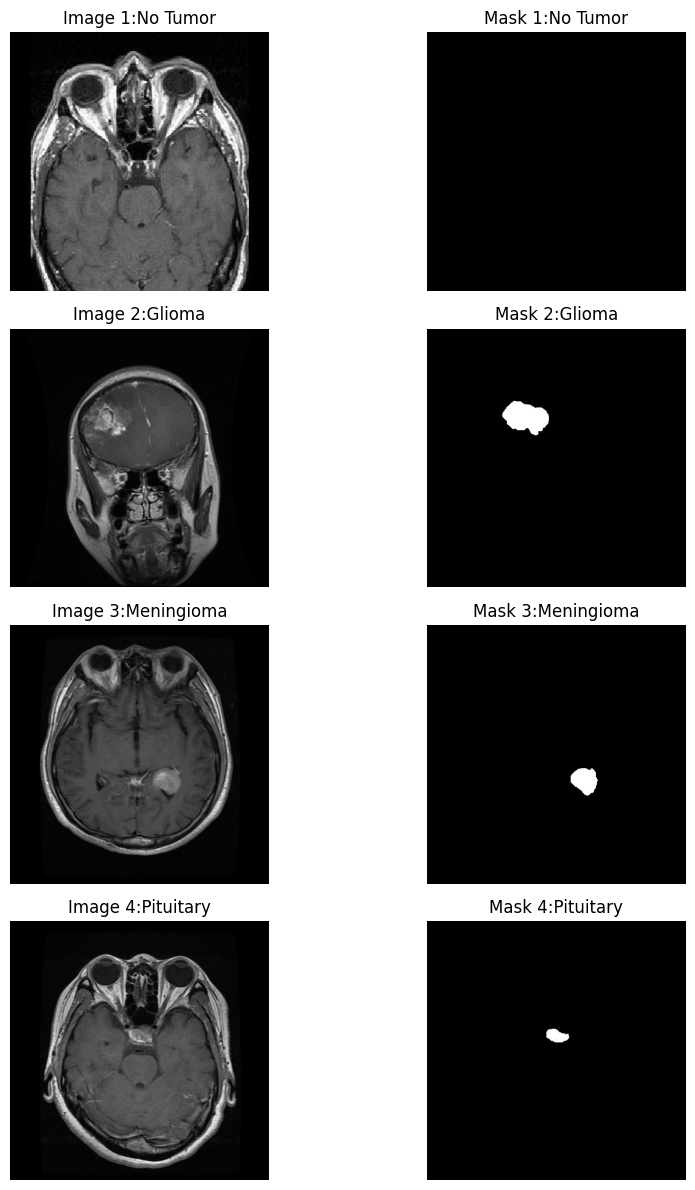

In [2]:
import cv2
import matplotlib.pyplot as plt


fig, axs = plt.subplots(4, 2, figsize=(10, 12))  # Adjusting the size for better visibility


img1 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/0/Tr-noTr_0000.jpg")
img2 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/0/Tr-noTr_0000_m.jpg")
img3 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/1/Tr-glTr_0000.jpg")
img4 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/1/Tr-glTr_0000_m.jpg")
img5 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/2/Tr-meTr_0001.jpg")
img6 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/2/Tr-meTr_0001_m.jpg")
img7 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/3/Tr-piTr_0000.jpg")
img8 = cv2.imread("/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/3/Tr-piTr_0000_m.jpg")



# Plot the images
axs[0, 0].imshow(img1)
axs[0, 0].set_title("Image 1:No Tumor")
axs[0, 0].axis('off')

axs[0, 1].imshow(img2)
axs[0, 1].set_title("Mask 1:No Tumor")
axs[0, 1].axis('off')

axs[1, 0].imshow(img3)
axs[1, 0].set_title("Image 2:Glioma")
axs[1, 0].axis('off')

axs[1, 1].imshow(img4)
axs[1, 1].set_title("Mask 2:Glioma")
axs[1, 1].axis('off')

axs[2, 0].imshow(img5)
axs[2, 0].set_title("Image 3:Meningioma")
axs[2, 0].axis('off')

axs[2, 1].imshow(img6)
axs[2, 1].set_title("Mask 3:Meningioma")
axs[2, 1].axis('off')

axs[3, 0].imshow(img7)
axs[3, 0].set_title("Image 4:Pituitary")
axs[3, 0].axis('off')

axs[3, 1].imshow(img8)
axs[3, 1].set_title("Mask 4:Pituitary")
axs[3, 1].axis('off')

plt.tight_layout()  
plt.show()


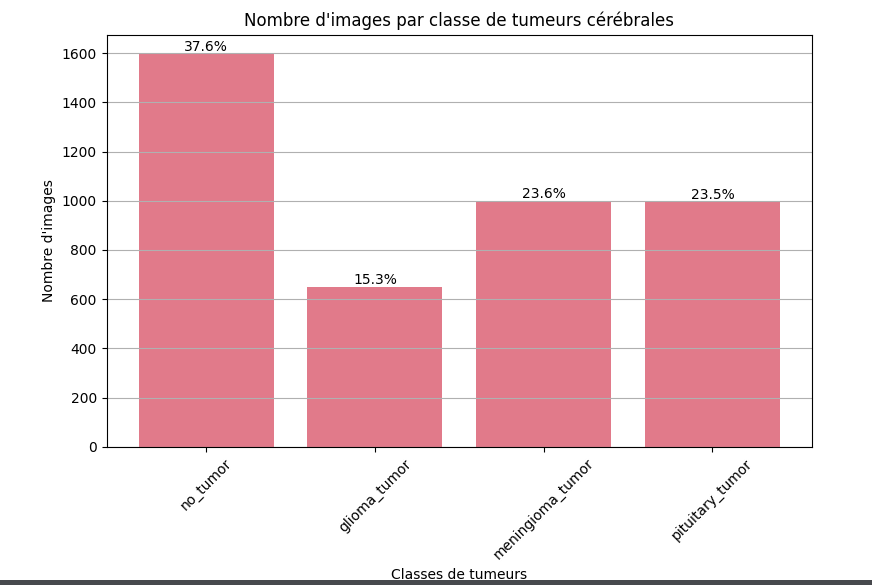


**Data Preprocessing**

In [3]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from albumentations import HorizontalFlip, VerticalFlip, Rotate, Compose

DATASET_PATH = r"/kaggle/input/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset"
CLASSES = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
TARGET_SIZE = (128, 128)

# Augmentation function
def augment_data(image, mask):
    transform = Compose([
        HorizontalFlip(p=0.5),
        VerticalFlip(p=0.5),
        Rotate(limit=45, p=0.5)
    ])
    augmented = transform(image=image, mask=mask)
    return augmented["image"], augmented["mask"]

# Load dataset and balance classes
def load_balanced_data(data_path, classes, target_size):
    images = []
    masks = []
    labels = []
    class_counts = [0] * len(classes)
    
    for class_index, class_name in enumerate(classes):
        image_folder = os.path.join(data_path, 'image', str(class_index))
        mask_folder = os.path.join(data_path, 'mask', str(class_index))
        
        if not os.path.exists(image_folder) or not os.path.exists(mask_folder):
            continue

        for image_name in tqdm(os.listdir(image_folder), desc=f"Loading {class_name}"):
            if image_name.endswith(('.jpg', '.png')):
                image_path = os.path.join(image_folder, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    continue
                
                image = cv2.resize(image, target_size)
                image = image / 255.0  

                mask_name = image_name.replace('.jpg', '_m.jpg').replace('.png', '_m.png')
                mask_path = os.path.join(mask_folder, mask_name)

                if os.path.exists(mask_path):
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    if mask is None:
                        continue

                    mask = cv2.resize(mask, target_size)
                    mask = mask / 255.0  

                    images.append(image)
                    masks.append(mask)
                    labels.append(class_index)
                    class_counts[class_index] += 1
    
    max_count = max(class_counts)
    
    for i in range(len(images)):
        while class_counts[labels[i]] < max_count:
            aug_image, aug_mask = augment_data(images[i], masks[i])
            images.append(aug_image)
            masks.append(aug_mask)
            labels.append(labels[i])
            class_counts[labels[i]] += 1
    
    images = np.array(images, dtype=np.float32).reshape(-1, 128, 128, 1)
    masks = np.array(masks, dtype=np.float32).reshape(-1, 128, 128, 1)
    labels = np.array(labels, dtype=np.int32)
    
    return images, masks, labels

# Data Splitting
def split_data(images, masks, labels, test_size=0.2, val_size=0.1):
    Img_train, Img_test, label_train, label_test, mask_train, mask_test = train_test_split(
        images, labels, masks, test_size=test_size, random_state=42, stratify=labels
    )

    Img_train, Img_val, label_train, label_val, mask_train, mask_val = train_test_split(
        Img_train, label_train, mask_train, test_size=val_size, random_state=42, stratify=label_train
    )
    
    return Img_train, Img_val, Img_test, label_train, label_val, label_test, mask_train, mask_val, mask_test

# Main execution
if __name__ == "__main__":
    images, masks, labels = load_balanced_data(DATASET_PATH, CLASSES, TARGET_SIZE)
    print(f"Total Images: {images.shape[0]}, Total Masks: {masks.shape[0]}, Total Labels: {labels.shape[0]}")

    Img_train, Img_val, Img_test, label_train, label_val, label_test, mask_train, mask_val, mask_test = split_data(
        images, masks, labels, test_size=0.2, val_size=0.1
    )

    print(f"Training data: {Img_train.shape[0]}")
    print(f"Validation data: {Img_val.shape[0]}")
    print(f"Test data: {Img_test.shape[0]}")


Loading pituitary_tumor: 100%|██████████| 994/994 [00:14<00:00, 68.57it/s]


Total Images: 6380, Total Masks: 6380, Total Labels: 6380
Training data: 4593
Validation data: 511
Test data: 1276


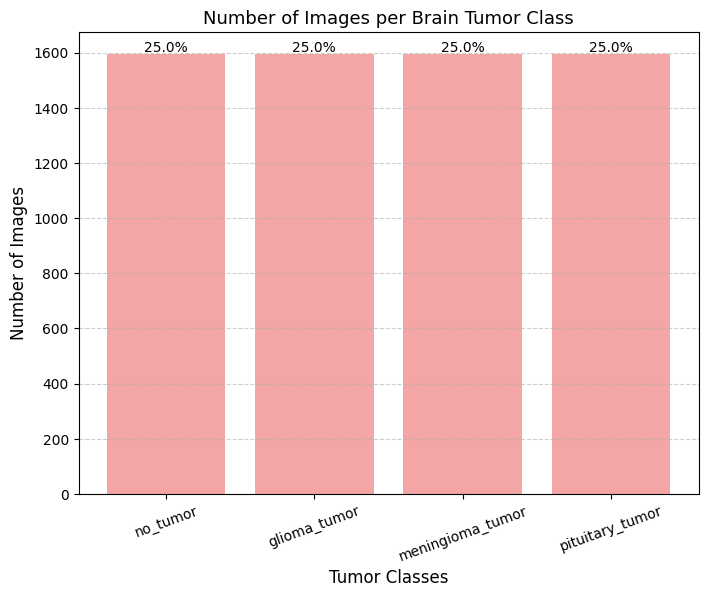

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


unique, counts = np.unique(labels, return_counts=True)
class_counts = dict(zip(CLASSES, counts))


total_images = sum(class_counts.values())
percentages = [(count / total_images) * 100 for count in class_counts.values()]


plt.figure(figsize=(8, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='lightcoral', alpha=0.7)


for bar, percentage in zip(bars, percentages):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{percentage:.1f}%', ha='center', fontsize=10)


plt.xlabel('Tumor Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Number of Images per Brain Tumor Class', fontsize=13)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.show()


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose, 
                                     concatenate, BatchNormalization, Dropout)
from tensorflow.keras.regularizers import l2

def unet_model(input_size=(128, 128, 1)):
    inputs = Input(input_size)
    reg = l2(0.0001)  # L2 Regularization 

    # Encoder (Down Sampling)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c1)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(0.3)(p1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c2)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(0.3)(p2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p2)
    c3 = BatchNormalization()(c3)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c3)
    c3 = BatchNormalization()(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(0.4)(p3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p3)
    c4 = BatchNormalization()(c4)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c4)
    c4 = BatchNormalization()(c4)
    p4 = MaxPooling2D((2, 2))(c4)
    p4 = Dropout(0.4)(p4)

    # Bottleneck 
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(p4)
    c5 = BatchNormalization()(c5)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c5)
    c5 = BatchNormalization()(c5)
    c5 = Dropout(0.5)(c5)

    # Decoder (Up Sampling)
    u6 = Conv2DTranspose(512, (2, 2), strides=(2,2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u6)
    c6 = BatchNormalization()(c6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c6)
    c6 = BatchNormalization()(c6)

    u7 = Conv2DTranspose(256, (2, 2), strides=(2,2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u7)
    c7 = BatchNormalization()(c7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c7)
    c7 = BatchNormalization()(c7)

    u8 = Conv2DTranspose(128, (2, 2), strides=(2,2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u8)
    c8 = BatchNormalization()(c8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c8)
    c8 = BatchNormalization()(c8)

    u9 = Conv2DTranspose(64, (2, 2), strides=(2,2), padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(u9)
    c9 = BatchNormalization()(c9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=reg)(c9)
    c9 = BatchNormalization()(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs, outputs)
    return model


In [6]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

def dice_coef(mask_true, mask_pred, smooth=1e-6):
    mask_true_f = tf.keras.backend.flatten(mask_true)
    mask_pred_f = tf.keras.backend.flatten(mask_pred)
    intersection = tf.keras.backend.sum(mask_true_f * mask_pred_f)
    
    return (2. * intersection + smooth) / (tf.keras.backend.sum(mask_true_f) + tf.keras.backend.sum(mask_pred_f) + smooth)

def dice_loss(mask_true, mask_pred):
    return 1 - dice_coef(mask_true, mask_pred)

def iou_coef(mask_true, mask_pred, smooth=1e-6):
    mask_true_f = tf.keras.backend.flatten(mask_true)
    mask_pred_f = tf.keras.backend.flatten(mask_pred)
    intersection = tf.keras.backend.sum(mask_true_f * mask_pred_f)
    union = tf.keras.backend.sum(mask_true_f) + tf.keras.backend.sum(mask_pred_f) - intersection
    
    return (intersection + smooth) / (union + smooth)


model = unet_model()


model.compile(optimizer=Adam(learning_rate=0.0001), loss=dice_loss, metrics=["accuracy",dice_coef, iou_coef])


model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 128, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 64, 64, 64)     │              0 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 128)    │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64, 64, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 32, 32, 128)    │              0 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 32, 32, 256)    │          1,024 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ batch_normalization_4… │
├──────────────────────

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:

import pickle


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  
    patience=3,  
    min_lr=1e-6  
)


history = model.fit(
    Img_train, mask_train,
    validation_data=(Img_val, mask_val),
    epochs=50,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]  
)



with open('history1.pkl', 'wb') as f:
    pickle.dump(history.history, f)

model.save("best_model.h5")
print("Model and History Saved 100%")





Epoch 1/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 97s 211ms/step - accuracy: 0.7687 - dice_coef: 0.1026 - iou_coef: 0.0548 - loss: 1.3115 - val_accuracy: 0.9798 - val_dice_coef: 0.0022 - val_iou_coef: 0.0011 - val_loss: 1.2457 - learning_rate: 1.0000e-04
Epoch 2/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.9415 - dice_coef: 0.2477 - iou_coef: 0.1428 - loss: 0.9812 - val_accuracy: 0.8883 - val_dice_coef: 0.1654 - val_iou_coef: 0.0906 - val_loss: 1.0268 - learning_rate: 1.0000e-04
Epoch 3/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.9725 - dice_coef: 0.4024 - iou_coef: 0.2549 - loss: 0.7838 - val_accuracy: 0.9846 - val_dice_coef: 0.6695 - val_iou_coef: 0.5070 - val_loss: 0.5031 - learning_rate: 1.0000e-04
Epoch 4/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 34s 116ms/step - accuracy: 0.9869 - dice_coef: 0.5817 - iou_coef: 0.4184 - loss: 0.5877 - val_accuracy: 0.9866 - val_dice_coef: 0.7086 - val_iou_coef: 0.5546 - val_loss: 0.4549 - learning_rate: 1.0000e-04
Epoch 5/50
288/288 ━

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


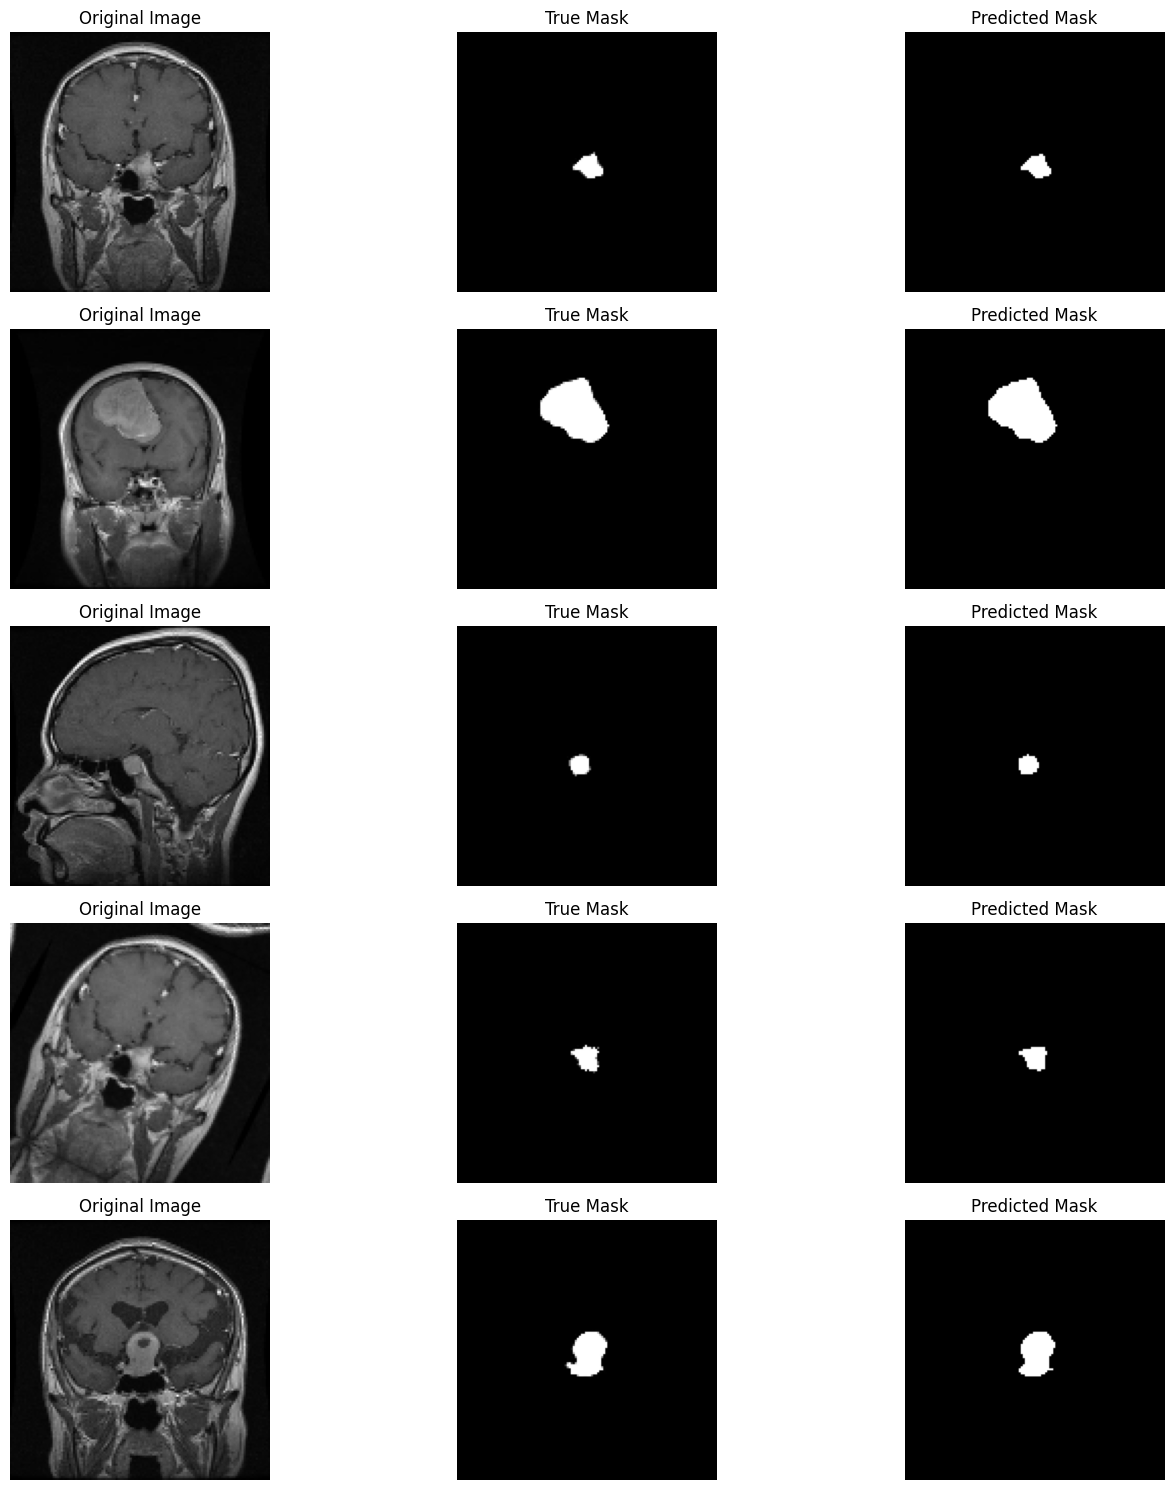

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def test_model(model, Img_test, mask_test, num_samples=5):
  
    indices = np.random.choice(len(Img_test), num_samples, replace=False)  

    plt.figure(figsize=(15, num_samples * 3))

    for i, idx in enumerate(indices):
        test_image = Img_test[idx]
        true_mask = mask_test[idx]

        
        test_image_input = np.expand_dims(test_image, axis=0)

        
        pred_mask = model.predict(test_image_input)[0]  

        
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        
        plt.subplot(num_samples, 3, i * 3 + 1)
        plt.imshow(test_image, cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 2)
        plt.imshow(true_mask, cmap='gray')
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()



test_model(model, Img_test, mask_test, num_samples=5)


In [15]:

test_loss,test_acc,test_dice,test_iou = model.evaluate(Img_test, mask_test, batch_size=16)


print(f"Test Loss (Dice Loss) : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Dice Coefficient: {test_dice:.4f}")
print(f"Test IoU Coefficient: {test_iou:.4f}")



80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9938 - dice_coef: 0.9470 - iou_coef: 0.9005 - loss: 0.1171
Test Loss (Dice Loss) : 0.1222
Test Accuracy : 0.9936
Test Dice Coefficient: 0.9418
Test IoU Coefficient: 0.8917


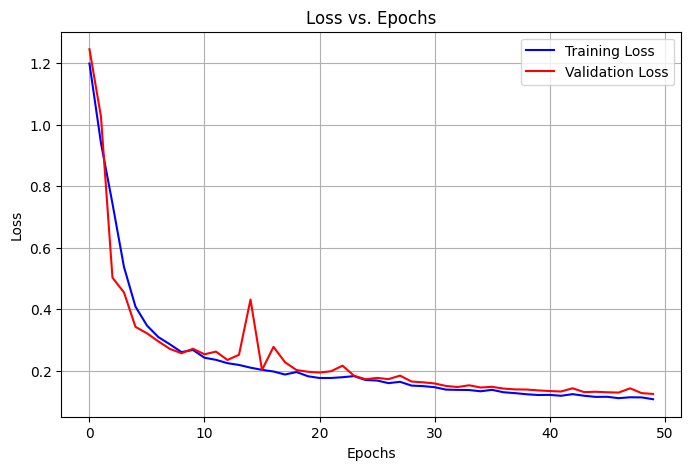

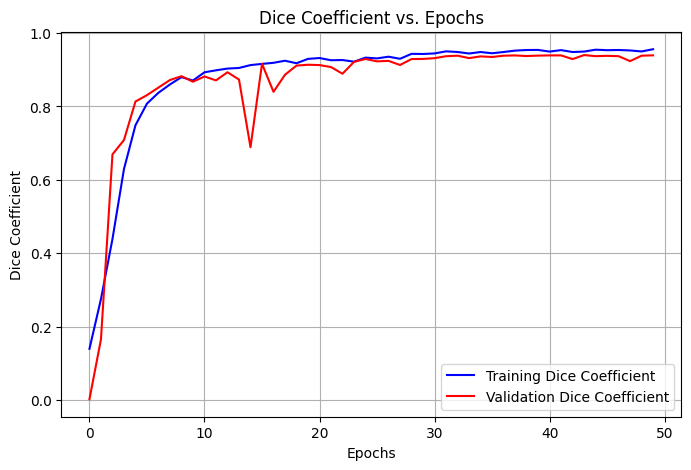

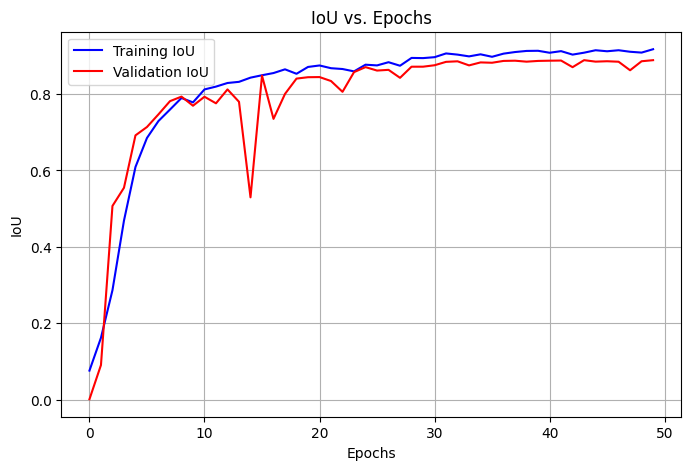

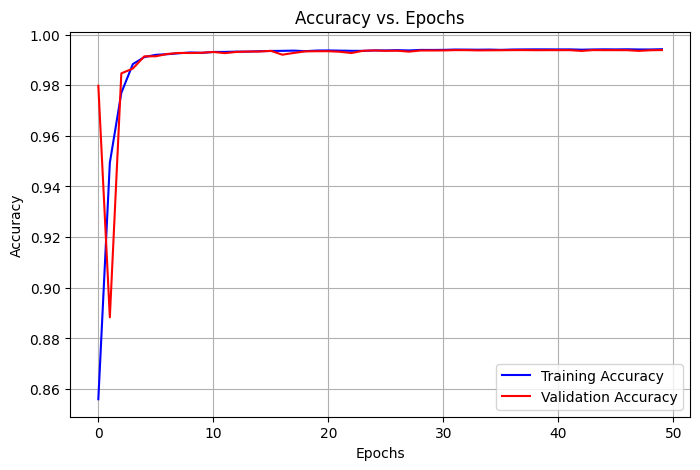

In [17]:
import matplotlib.pyplot as plt

# --- Loss Curve (Dice Loss) ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.legend()
plt.grid()
plt.show()


# --- Dice Coefficient Curve ---
train_dice = history.history['dice_coef']
val_dice = history.history['val_dice_coef']

plt.figure(figsize=(8, 5))
plt.plot(train_dice, label='Training Dice Coefficient', color='blue')
plt.plot(val_dice, label='Validation Dice Coefficient', color='red')

plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Dice Coefficient vs. Epochs')
plt.legend()
plt.grid()
plt.show()


# --- IoU Curve ---
train_iou = history.history['iou_coef']
val_iou = history.history['val_iou_coef']

plt.figure(figsize=(8, 5))
plt.plot(train_iou, label='Training IoU', color='blue')
plt.plot(val_iou, label='Validation IoU', color='red')

plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('IoU vs. Epochs')
plt.legend()
plt.grid()
plt.show()


# --- Accuracy Curve ---
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='red')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epochs')
plt.legend()
plt.grid()
plt.show()



In [ ]:
from graphviz import Digraph

def visualize_unet():
    dot = Digraph(format='png')
    
    # Encoder
    dot.node('Input', 'Input (128x128x1)')
    dot.node('C1', 'Conv 3x3, 64\nBatchNorm\nReLU')
    dot.node('C2', 'Conv 3x3, 64\nBatchNorm\nReLU')
    dot.node('P1', 'Max Pool 2x2\nDropout')
    
    dot.node('C3', 'Conv 3x3, 128\nBatchNorm\nReLU')
    dot.node('C4', 'Conv 3x3, 128\nBatchNorm\nReLU')
    dot.node('P2', 'Max Pool 2x2\nDropout')
    
    dot.node('C5', 'Conv 3x3, 256\nBatchNorm\nReLU')
    dot.node('C6', 'Conv 3x3, 256\nBatchNorm\nReLU')
    dot.node('P3', 'Max Pool 2x2\nDropout')
    
    dot.node('Bottleneck', 'Conv 3x3, 512\nBatchNorm\nReLU\nDropout')
    
    # Decoder
    dot.node('U1', 'UpConv 2x2, 256')
    dot.node('M1', 'Merge with C6')
    dot.node('C7', 'Conv 3x3, 256\nBatchNorm\nReLU')
    dot.node('C8', 'Conv 3x3, 256\nBatchNorm\nReLU')
    
    dot.node('U2', 'UpConv 2x2, 128')
    dot.node('M2', 'Merge with C4')
    dot.node('C9', 'Conv 3x3, 128\nBatchNorm\nReLU')
    dot.node('C10', 'Conv 3x3, 128\nBatchNorm\nReLU')
    
    dot.node('U3', 'UpConv 2x2, 64')
    dot.node('M3', 'Merge with C2')
    dot.node('C11', 'Conv 3x3, 64\nBatchNorm\nReLU')
    dot.node('C12', 'Conv 3x3, 64\nBatchNorm\nReLU')
    
    dot.node('Output', 'Conv 1x1, Sigmoid')
    
    # Encoder connections
    dot.edge('Input', 'C1')
    dot.edge('C1', 'C2')
    dot.edge('C2', 'P1')
    dot.edge('P1', 'C3')
    dot.edge('C3', 'C4')
    dot.edge('C4', 'P2')
    dot.edge('P2', 'C5')
    dot.edge('C5', 'C6')
    dot.edge('C6', 'P3')
    dot.edge('P3', 'Bottleneck')
    
    # Decoder connections
    dot.edge('Bottleneck', 'U1')
    dot.edge('U1', 'M1')
    dot.edge('M1', 'C7')
    dot.edge('C7', 'C8')
    dot.edge('C8', 'U2')
    
    dot.edge('U2', 'M2')
    dot.edge('M2', 'C9')
    dot.edge('C9', 'C10')
    dot.edge('C10', 'U3')
    
    dot.edge('U3', 'M3')
    dot.edge('M3', 'C11')
    dot.edge('C11', 'C12')
    dot.edge('C12', 'Output')
    
    return dot

# Save and render
unet_graph = visualize_unet()
unet_graph.render('unet_model')
